In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from src.models import TinyCNN
from src.client import Client
from src.server import Server
from src.reliability import ReliabilityTracker

from src.utils import (
    load_pathmnist,
    partition_dirichlet
)


In [2]:
train_dataset, test_dataset = load_pathmnist()

print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

Train Samples: 89996
Test Samples: 7180


In [3]:
client_datasets = partition_dirichlet(
    train_dataset,
    num_clients=5,
    alpha=0.5
)

print("Number of Clients:", len(client_datasets))

Number of Clients: 5


In [4]:
client_loaders = []

for dataset in client_datasets:

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=True
    )

    client_loaders.append(loader)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Client loaders ready")

Client loaders ready


In [5]:
global_model = TinyCNN(num_classes=9)

print("Global model created")

Global model created


In [6]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model.to(device)

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = (
                labels.squeeze()
                .long()
                .to(device)
            )

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = correct / total

    return accuracy

In [7]:
def fedavg(weights_list):

    avg_weights = {}

    for key in weights_list[0].keys():

        avg_weights[key] = (
            weights_list[0][key]
            .clone()
            .float()
        )

        for i in range(
            1,
            len(weights_list)
        ):

            avg_weights[key] += (
                weights_list[i][key]
                .float()
            )

        avg_weights[key] /= len(
            weights_list
        )

    return avg_weights

In [8]:
baseline_clients = []

for loader in client_loaders:

    model = TinyCNN(
        num_classes=9
    )

    model.load_state_dict(
        global_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    baseline_clients.append(
        client
    )

print(
    "Baseline clients created:",
    len(baseline_clients)
)

Baseline clients created: 5


In [9]:
baseline_accuracy = []

ROUNDS = 5

for rnd in range(ROUNDS):

    print(
        f"\n===== BASELINE ROUND {rnd+1} ====="
    )

    local_weights = []

    for client in baseline_clients:

        loss, reliability = client.train(
            epochs=1
        )

        local_weights.append(
            client.get_weights()
        )

    global_weights = fedavg(
        local_weights
    )

    global_model.load_state_dict(
        global_weights
    )

    for client in baseline_clients:

        client.set_weights(
            global_weights
        )

    acc = evaluate(
        global_model,
        test_loader
    )

    baseline_accuracy.append(
        acc
    )

    print(
        f"Accuracy = {acc:.4f}"
    )


===== BASELINE ROUND 1 =====
Accuracy = 0.5518

===== BASELINE ROUND 2 =====
Accuracy = 0.6519

===== BASELINE ROUND 3 =====
Accuracy = 0.7201

===== BASELINE ROUND 4 =====
Accuracy = 0.7840

===== BASELINE ROUND 5 =====
Accuracy = 0.6783


In [10]:
print("Final Baseline Accuracy:", baseline_accuracy[-1])

import pandas as pd

baseline_results = pd.DataFrame({
    "Round": list(range(1, len(baseline_accuracy)+1)),
    "Accuracy": baseline_accuracy
})

baseline_results

Final Baseline Accuracy: 0.6782729805013927


,Round,Accuracy
0,1,0.551811
1,2,0.651950
2,3,0.720056
3,4,0.783983
4,5,0.678273


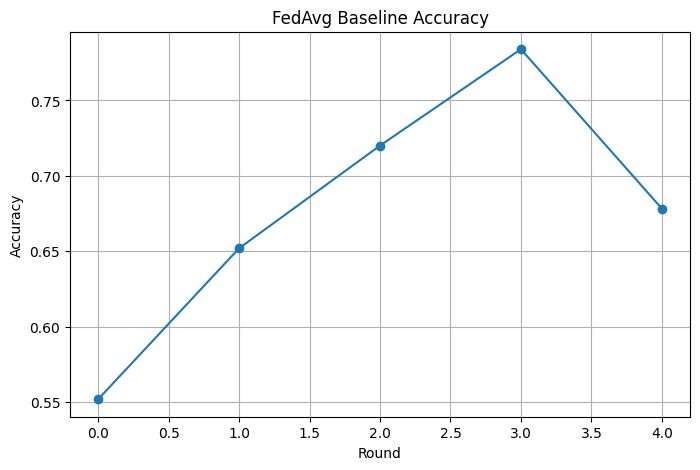

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    baseline_accuracy,
    marker="o"
)

plt.title(
    "FedAvg Baseline Accuracy"
)

plt.xlabel("Round")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [12]:
from src.models import TinyCNN
from src.server import Server
from src.reliability import ReliabilityTracker

arahfl_model = TinyCNN(num_classes=9)

tracker = ReliabilityTracker()

server = Server(
    global_model=arahfl_model,
    reliability_tracker=tracker
)

print("ARAHFL components ready")

ARAHFL components ready


In [13]:
arahfl_clients = []

for loader in client_loaders:

    model = TinyCNN(num_classes=9)

    model.load_state_dict(
        arahfl_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    arahfl_clients.append(client)

print(
    "ARAHFL clients created:",
    len(arahfl_clients)
)

ARAHFL clients created: 5


In [14]:
arahfl_accuracy = []

ROUNDS = 5

for rnd in range(ROUNDS):

    print(f"\n===== ARAHFL ROUND {rnd+1} =====")

    server.client_updates = []
    server.client_ids = []

    for client_id, client in enumerate(arahfl_clients):

        loss, reliability = client.train(
            epochs=1
        )

        tracker.compute_reliability(
            client_id=client_id,
            loss=loss
        )

        server.add_client_update(
            client_id,
            client.get_weights()
        )

        print(
            f"Client {client_id} | "
            f"Loss={loss:.4f} | "
            f"Reliability={reliability:.4f}"
        )

    global_weights = server.aggregate()

    for client in arahfl_clients:

        client.set_weights(
            global_weights
        )

    acc = evaluate(
        arahfl_model,
        test_loader
    )

    server.log_global_accuracy(acc)

    arahfl_accuracy.append(acc)

    print(
        f"Global Accuracy={acc:.4f}"
    )


===== ARAHFL ROUND 1 =====
Client 0 | Loss=0.8440 | Reliability=0.5423
Client 1 | Loss=1.3039 | Reliability=0.4341
Client 2 | Loss=1.2980 | Reliability=0.4352
Client 3 | Loss=1.3026 | Reliability=0.4343
Client 4 | Loss=0.9748 | Reliability=0.5064
Global Accuracy=0.5758

===== ARAHFL ROUND 2 =====
Client 0 | Loss=0.7826 | Reliability=0.5610
Client 1 | Loss=1.2479 | Reliability=0.4449
Client 2 | Loss=1.1622 | Reliability=0.4625
Client 3 | Loss=1.0764 | Reliability=0.4816
Client 4 | Loss=0.8714 | Reliability=0.5344
Global Accuracy=0.5068

===== ARAHFL ROUND 3 =====
Client 0 | Loss=0.7233 | Reliability=0.5803
Client 1 | Loss=1.1737 | Reliability=0.4601
Client 2 | Loss=1.1131 | Reliability=0.4732
Client 3 | Loss=1.0942 | Reliability=0.4775
Client 4 | Loss=0.8495 | Reliability=0.5407
Global Accuracy=0.6630

===== ARAHFL ROUND 4 =====
Client 0 | Loss=0.7424 | Reliability=0.5739
Client 1 | Loss=1.1119 | Reliability=0.4735
Client 2 | Loss=1.0651 | Reliability=0.4842
Client 3 | Loss=0.9779 | Re

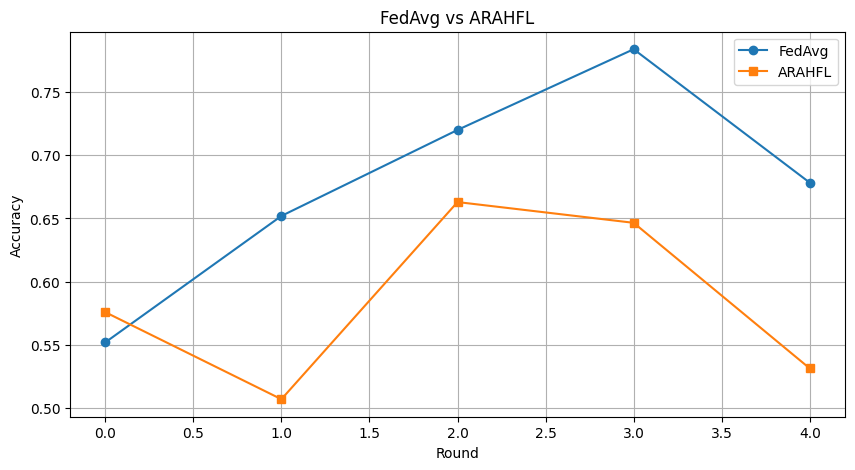

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    baseline_accuracy,
    marker="o",
    label="FedAvg"
)

plt.plot(
    arahfl_accuracy,
    marker="s",
    label="ARAHFL"
)

plt.xlabel("Round")

plt.ylabel("Accuracy")

plt.title(
    "FedAvg vs ARAHFL"
)

plt.legend()

plt.grid(True)

plt.show()

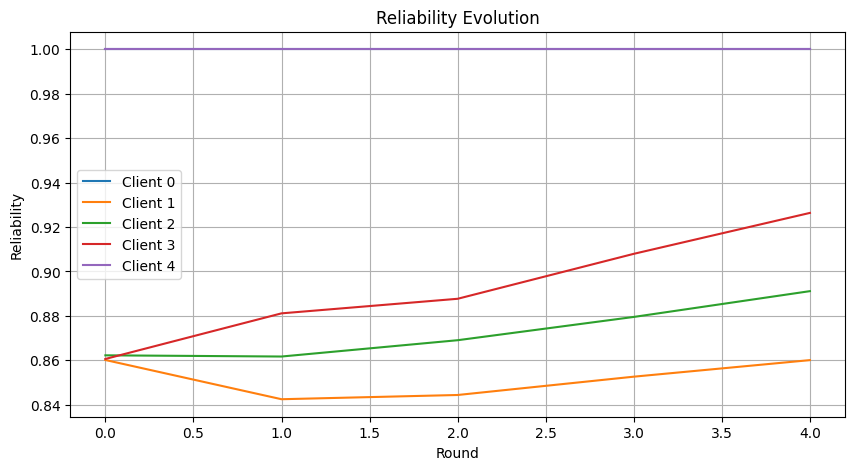

In [16]:
reliability_history = server.get_reliability_history()

import numpy as np

reliability_history = np.array(
    reliability_history
)

plt.figure(figsize=(10,5))

for client_id in range(
    reliability_history.shape[1]
):

    plt.plot(
        reliability_history[:, client_id],
        label=f"Client {client_id}"
    )

plt.title(
    "Reliability Evolution"
)

plt.xlabel("Round")

plt.ylabel("Reliability")

plt.legend()

plt.grid(True)

plt.show()